# Red Wine Quality Prediction – Exploratory Data Analysis

## Objective
The objective of this notebook is to explore the red wine quality dataset, understand its structure, identify potential data quality issues, and justify the preprocessing choices used later in the modeling phase.

This notebook is limited to exploratory data analysis (EDA). The training, tuning, and evaluation of machine learning models are implemented separately in Python scripts.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# Display options
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

# Plot style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [21]:
cwd = Path.cwd()

candidate_paths = [
    cwd / "data" / "raw" / "winequality-red.csv",
    cwd.parent / "data" / "raw" / "winequality-red.csv",
]

data_path = None
for path in candidate_paths:
    print("Testing:", path)
    print("Exists:", path.exists())
    if path.exists():
        data_path = path
        break

if data_path is None:
    raise FileNotFoundError("winequality-red.csv not found in expected locations.")

print("\nSelected path:", data_path)

data = pd.read_csv(data_path, sep=",")
data.columns = data.columns.str.strip().str.lower()

data.head()

Testing: c:\Users\fatna\OneDrive\Machine Learning\Projet\data\raw\winequality-red.csv
Exists: True

Selected path: c:\Users\fatna\OneDrive\Machine Learning\Projet\data\raw\winequality-red.csv


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,ph,sulphates,alcohol,quality
0,7.4000,0.7000,0.0000,1.9000,0.0760,11.0000,34.0000,0.9978,3.5100,0.5600,9.4000,5
1,7.8000,0.8800,0.0000,2.6000,0.0980,25.0000,67.0000,0.9968,3.2000,0.6800,9.8000,5
2,7.8000,0.7600,0.0400,2.3000,0.0920,15.0000,54.0000,0.9970,3.2600,0.6500,9.8000,5
3,11.2000,0.2800,0.5600,1.9000,0.0750,17.0000,60.0000,0.9980,3.1600,0.5800,9.8000,6
4,7.4000,0.7000,0.0000,1.9000,0.0760,11.0000,34.0000,0.9978,3.5100,0.5600,9.4000,5


## Dataset overview

The dataset contains physicochemical characteristics of red wines, as well as a quality score assigned to each wine.

The first step is to inspect the dataset structure, variable names, and general dimensions before conducting more detailed analysis.

In [22]:
print("Shape of the dataset:", data.shape)
print("\nColumns:")
print(data.columns.tolist())

Shape of the dataset: (1599, 12)

Columns:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'ph', 'sulphates', 'alcohol', 'quality']


In [23]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   ph                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [24]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   ph                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [25]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0000,8.3196,1.7411,4.6000,7.1000,7.9000,9.2000,15.9000
volatile acidity,1599.0000,0.5278,0.1791,0.1200,0.3900,0.5200,0.6400,1.5800
citric acid,1599.0000,0.2710,0.1948,0.0000,0.0900,0.2600,0.4200,1.0000
residual sugar,1599.0000,2.5388,1.4099,0.9000,1.9000,2.2000,2.6000,15.5000
chlorides,1599.0000,0.0875,0.0471,0.0120,0.0700,0.0790,0.0900,0.6110
free sulfur dioxide,1599.0000,15.8749,10.4602,1.0000,7.0000,14.0000,21.0000,72.0000
total sulfur dioxide,1599.0000,46.4678,32.8953,6.0000,22.0000,38.0000,62.0000,289.0000
density,1599.0000,0.9967,0.0019,0.9901,0.9956,0.9968,0.9978,1.0037
ph,1599.0000,3.3111,0.1544,2.7400,3.2100,3.3100,3.4000,4.0100
sulphates,1599.0000,0.6581,0.1695,0.3300,0.5500,0.6200,0.7300,2.0000


In [26]:
missing_values = data.isnull().sum()
missing_values

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
ph                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

## Missing values

The dataset does not contain missing values. This is useful because no imputation strategy is required before analysis or modeling.

In [27]:
duplicate_count = data.duplicated().sum()
print(f"Number of duplicated rows: {duplicate_count}")

Number of duplicated rows: 240


## Duplicate observations

The dataset contains duplicated rows. Since duplicated observations may bias the learning process by artificially reinforcing repeated patterns, their presence must be examined carefully.

A comparison before and after duplicate removal will be useful later to justify the preprocessing strategy.

## Distribution of the original target variable

Before transforming the target into a binary variable, it is useful to inspect the distribution of the original quality score.

In [32]:
quality_counts = data["quality"].value_counts().sort_index()
quality_counts

quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

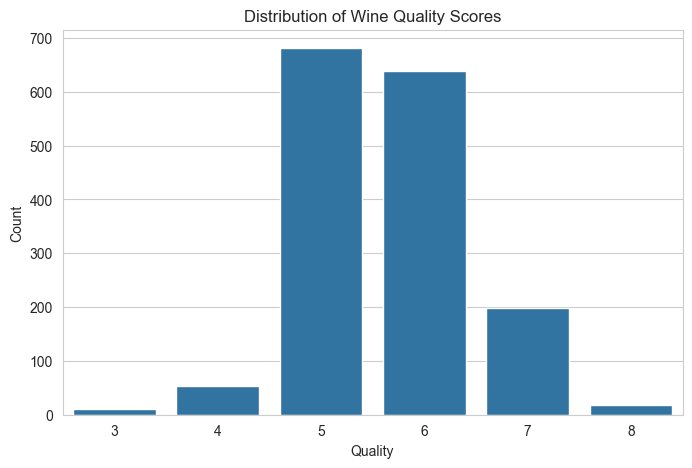

In [33]:
plt.figure(figsize=(8, 5))
sns.countplot(x="quality", data=data)
plt.title("Distribution of Wine Quality Scores")
plt.xlabel("Quality")
plt.ylabel("Count")
plt.show()

In [34]:
corr_with_quality = data.corr(numeric_only=True)["quality"].sort_values(ascending=False)
corr_with_quality

quality                 1.0000
alcohol                 0.4762
sulphates               0.2514
citric acid             0.2264
fixed acidity           0.1241
residual sugar          0.0137
free sulfur dioxide    -0.0507
ph                     -0.0577
chlorides              -0.1289
density                -0.1749
total sulfur dioxide   -0.1851
volatile acidity       -0.3906
Name: quality, dtype: float64

## Correlation with wine quality

The correlation analysis provides a first indication of which physicochemical variables may be associated with wine quality.

Initial results suggest that alcohol tends to be positively associated with quality, while volatile acidity tends to be negatively associated with it.

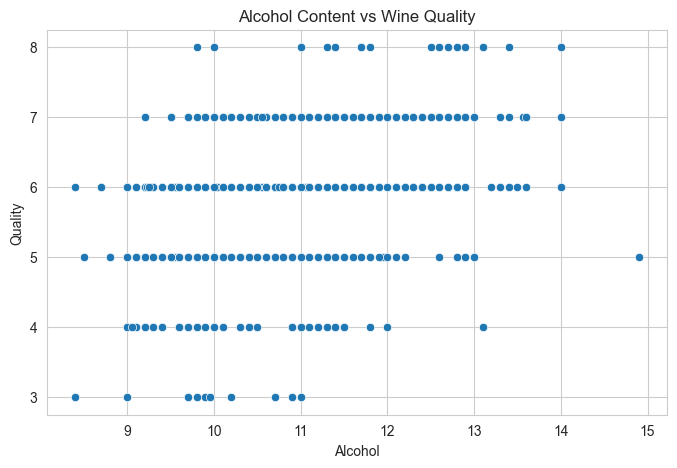

In [35]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x="alcohol", y="quality", data=data)
plt.title("Alcohol Content vs Wine Quality")
plt.xlabel("Alcohol")
plt.ylabel("Quality")
plt.show()

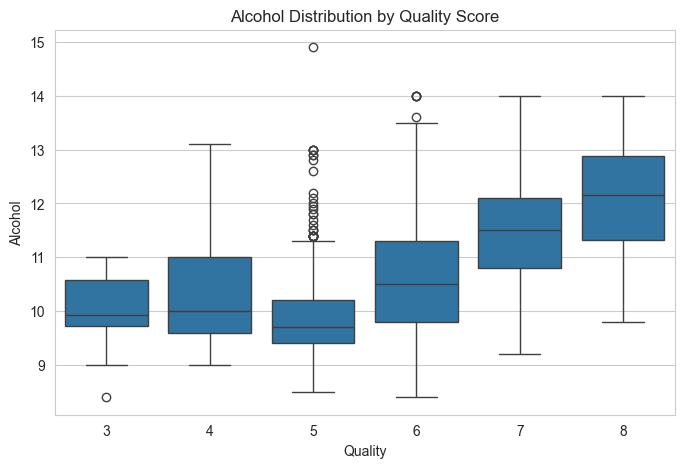

In [36]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="quality", y="alcohol", data=data)
plt.title("Alcohol Distribution by Quality Score")
plt.xlabel("Quality")
plt.ylabel("Alcohol")
plt.show()

## Creation of a binary target

To make the prediction problem more interpretable and more suitable for binary classification models, the original quality score is transformed into a binary target:

- 1 if quality >= 6
- 0 otherwise

This creates a variable indicating whether a wine is of relatively good quality or not.

In [37]:
data["good_quality"] = (data["quality"] >= 6).astype(int)

data[["quality", "good_quality"]].head()

,quality,good_quality
0,5,0
1,5,0
2,5,0
3,6,1
4,5,0


In [38]:
class_counts = data["good_quality"].value_counts().sort_index()
class_props = data["good_quality"].value_counts(normalize=True).sort_index() * 100

print("Class counts:")
print(class_counts)

print("\nClass proportions (%):")
print(class_props.round(2))

Class counts:
good_quality
0    744
1    855
Name: count, dtype: int64

Class proportions (%):
good_quality
0   46.5300
1   53.4700
Name: proportion, dtype: float64


In [39]:
class_counts = data["good_quality"].value_counts().sort_index()
class_props = data["good_quality"].value_counts(normalize=True).sort_index() * 100

print("Class counts:")
print(class_counts)

print("\nClass proportions (%):")
print(class_props.round(2))

Class counts:
good_quality
0    744
1    855
Name: count, dtype: int64

Class proportions (%):
good_quality
0   46.5300
1   53.4700
Name: proportion, dtype: float64


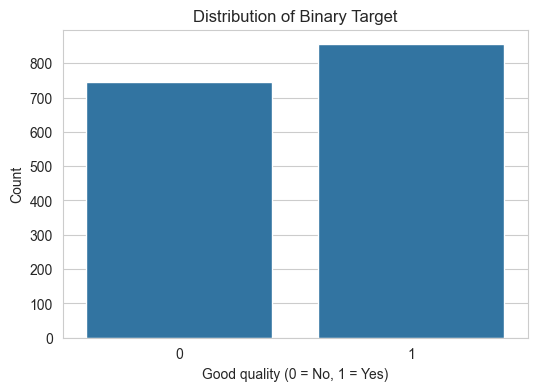

In [40]:
plt.figure(figsize=(6, 4))
sns.countplot(x="good_quality", data=data)
plt.title("Distribution of Binary Target")
plt.xlabel("Good quality (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

## Binary target distribution

The binary target is relatively balanced, with only a moderate class imbalance. This is convenient for classification because it reduces the risk of heavily biased predictions toward one class.

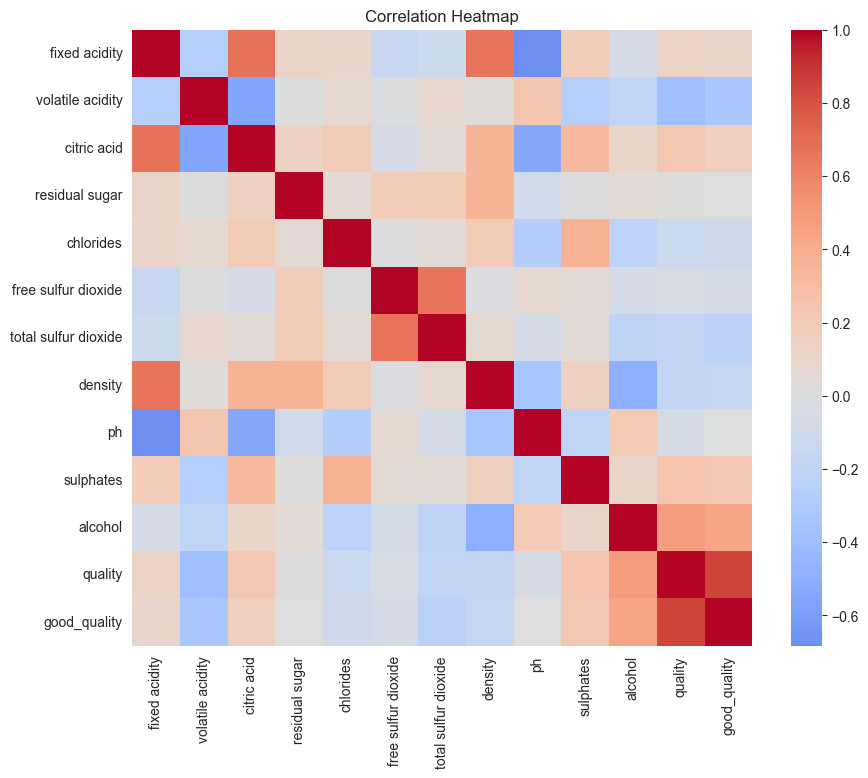

In [41]:
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

In [42]:
corr_binary = data.corr(numeric_only=True)["good_quality"].sort_values(ascending=False)
corr_binary

good_quality            1.0000
quality                 0.8483
alcohol                 0.4348
sulphates               0.2181
citric acid             0.1591
fixed acidity           0.0951
residual sugar         -0.0022
ph                     -0.0033
free sulfur dioxide    -0.0618
chlorides              -0.1095
density                -0.1591
total sulfur dioxide   -0.2320
volatile acidity       -0.3214
Name: good_quality, dtype: float64

In [43]:
corr_binary.drop(["quality", "good_quality"]).sort_values(key=abs, ascending=False)

alcohol                 0.4348
volatile acidity       -0.3214
total sulfur dioxide   -0.2320
sulphates               0.2181
citric acid             0.1591
density                -0.1591
chlorides              -0.1095
fixed acidity           0.0951
free sulfur dioxide    -0.0618
ph                     -0.0033
residual sugar         -0.0022
Name: good_quality, dtype: float64

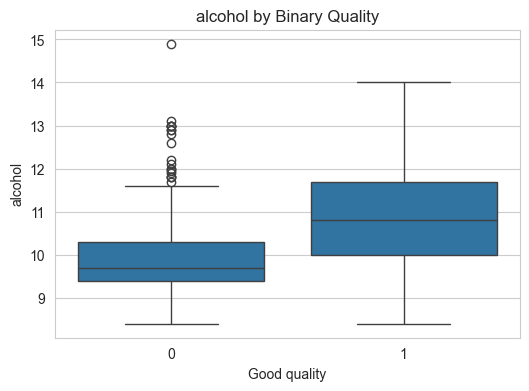

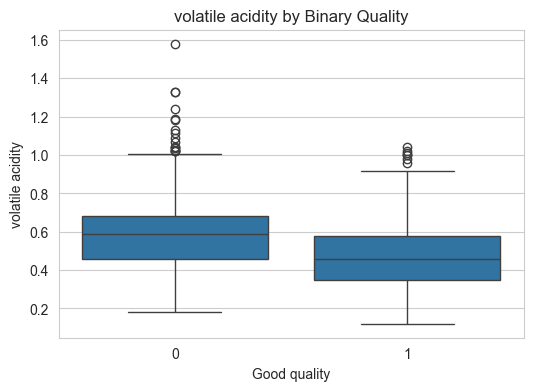

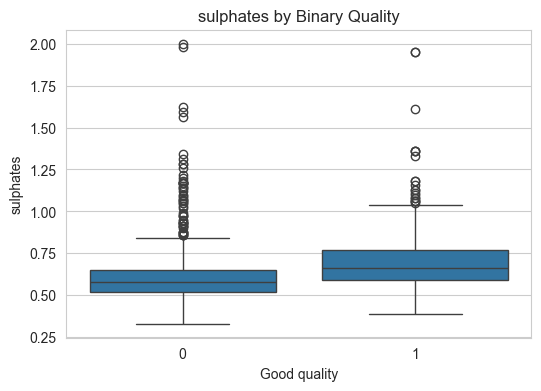

In [44]:
features_to_plot = ["alcohol", "volatile acidity", "sulphates"]

for col in features_to_plot:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x="good_quality", y=col, data=data)
    plt.title(f"{col} by Binary Quality")
    plt.xlabel("Good quality")
    plt.ylabel(col)
    plt.show()

In [45]:
data_nodup = data.drop_duplicates().copy()

print("Original shape:", data.shape)
print("Without duplicates:", data_nodup.shape)

print("\nOriginal target distribution:")
print(data["good_quality"].value_counts(normalize=True).sort_index().round(3))

print("\nWithout duplicates target distribution:")
print(data_nodup["good_quality"].value_counts(normalize=True).sort_index().round(3))

Original shape: (1599, 13)
Without duplicates: (1359, 13)

Original target distribution:
good_quality
0   0.4650
1   0.5350
Name: proportion, dtype: float64

Without duplicates target distribution:
good_quality
0   0.4710
1   0.5290
Name: proportion, dtype: float64


## EDA conclusion

The exploratory analysis highlights several important points:

1. The dataset contains no missing values, which simplifies preprocessing.
2. The dataset includes duplicated rows, which should be removed before model training.
3. The original quality score is concentrated around intermediate values, especially 5 and 6.
4. Transforming the target into a binary variable is a reasonable choice for a classification task.
5. Variables such as alcohol, volatile acidity, sulphates, and total sulfur dioxide appear to contain relevant predictive information.

These observations justify the next phase of the project, namely the implementation of classification models in separate Python scripts, with proper train/test splitting, cross-validation, hyperparameter tuning, and leakage control.